<a href="https://colab.research.google.com/github/jahidurmahim/Machine_Learning_Laboratory/blob/main/Back_propagation_gemini.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [39]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [40]:
pip install ucimlrepo

In [41]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
iris = fetch_ucirepo(id=53)

# data (as pandas dataframes)
X = iris.data.features
y = iris.data.targets

# metadata
print(iris.metadata)

# variable information
print(iris.variables)

{'uci_id': 53, 'name': 'Iris', 'repository_url': 'https://archive.ics.uci.edu/dataset/53/iris', 'data_url': 'https://archive.ics.uci.edu/static/public/53/data.csv', 'abstract': 'A small classic dataset from Fisher, 1936. One of the earliest known datasets used for evaluating classification methods.\n', 'area': 'Biology', 'tasks': ['Classification'], 'characteristics': ['Tabular'], 'num_instances': 150, 'num_features': 4, 'feature_types': ['Real'], 'demographics': [], 'target_col': ['class'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 1936, 'last_updated': 'Tue Sep 12 2023', 'dataset_doi': '10.24432/C56C76', 'creators': ['R. A. Fisher'], 'intro_paper': {'ID': 191, 'type': 'NATIVE', 'title': 'The Iris data set: In search of the source of virginica', 'authors': 'A. Unwin, K. Kleinman', 'venue': 'Significance, 2021', 'year': 2021, 'journal': 'Significance, 2021', 'DOI': '1740-9713.01589', 'URL': 'https://www.semanticscholar.org

In [42]:
df = pd.concat([X, y], axis=1)
df.head()

,sepal length,sepal width,petal length,petal width,class
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [43]:
df.shape

(150, 5)

In [44]:
df.isna().sum().T

,0
sepal length,0
sepal width,0
petal length,0
petal width,0
class,0


In [45]:
df.duplicated().sum()

np.int64(3)

In [46]:
outlier_summary = []

numeric_cols = df.select_dtypes(include='number').columns

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outlier_count = ((df[col] < lower) | (df[col] > upper)).sum()

    if outlier_count > 0:
        outlier_summary.append({
            'feature': col,
            'Q1': Q1,
            'Q3': Q3,
            'lower_bound': lower,
            'upper_bound': upper,
            'outlier_count': outlier_count
        })

outlier_df = pd.DataFrame(outlier_summary)
outlier_df

,feature,Q1,Q3,lower_bound,upper_bound,outlier_count
0,sepal width,2.8,3.3,2.05,4.05,4


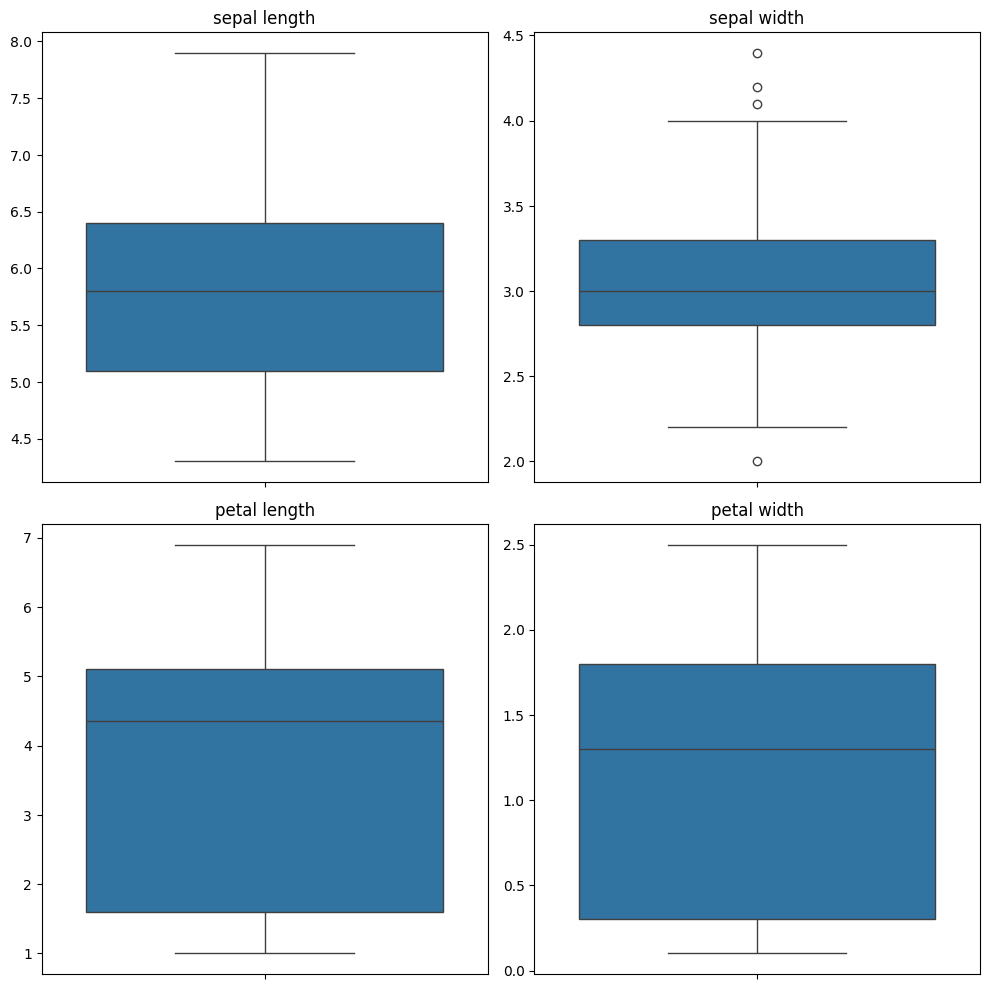

In [47]:
numeric_features = df.select_dtypes(include='number').columns.tolist()

rows = (len(numeric_features) + 1) // 2  # Adjust rows dynamically
cols = 2  # Set columns to 2 for better layout
fig, axes = plt.subplots(rows, cols, figsize=(10, 5 * rows))

axes = axes.flatten()

for i, feature in enumerate(numeric_features):
    sns.boxplot(y=df[feature], ax=axes[i])
    axes[i].set_title(feature)
    axes[i].set_ylabel('')

# Remove any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [48]:
capped_summary = []

numeric_features = df.select_dtypes(include='number').columns.tolist()

for feature in numeric_features:
    Q1 = df[feature].quantile(0.25)
    Q3 = df[feature].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    capped_summary.append([feature, Q1, Q3, lower, upper, 0])

capped_df = pd.DataFrame(capped_summary, columns=['feature','Q1','Q3','lower_bound','upper_bound','outlier_count'])

display(capped_df)

,feature,Q1,Q3,lower_bound,upper_bound,outlier_count
0,sepal length,5.1,6.4,3.15,8.35,0
1,sepal width,2.8,3.3,2.05,4.05,0
2,petal length,1.6,5.1,-3.65,10.35,0
3,petal width,0.3,1.8,-1.95,4.05,0


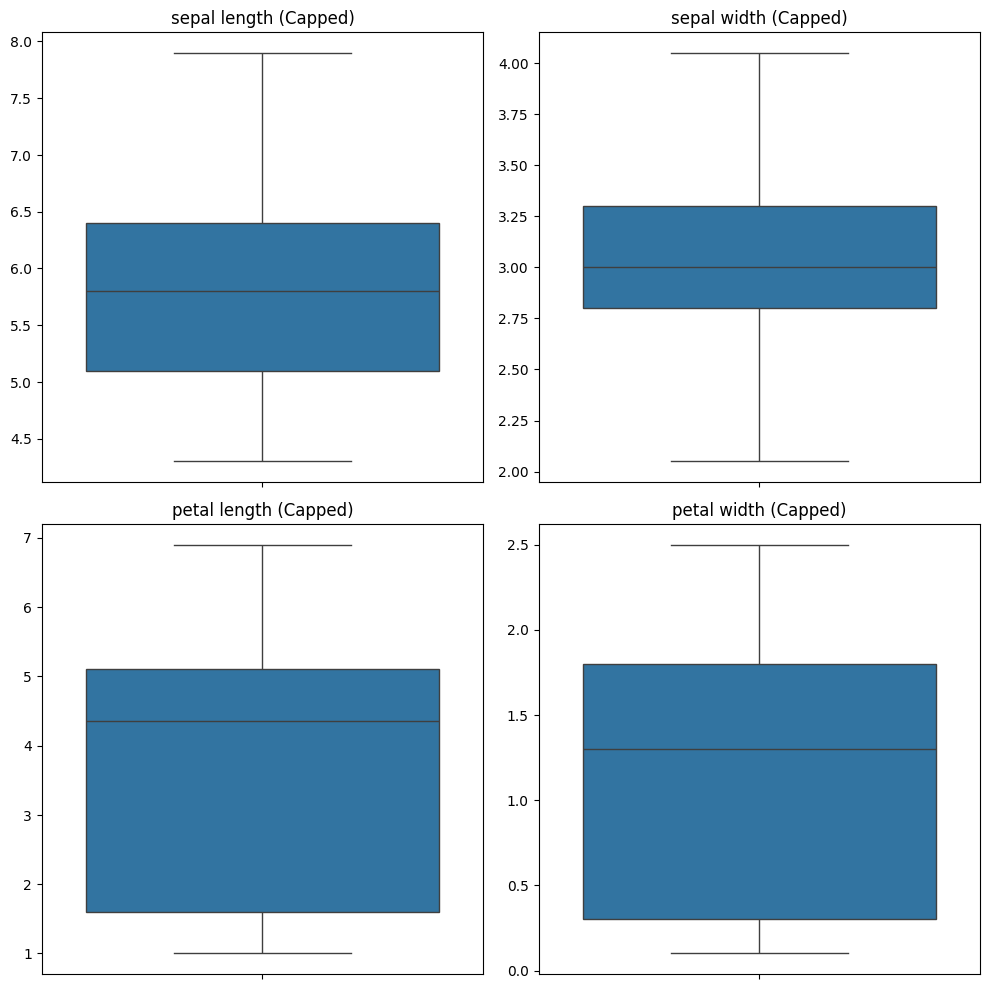

In [49]:
numeric_features_capped = df_capped.select_dtypes(include='number').columns.tolist()

rows_capped = (len(numeric_features_capped) + 1) // 2
cols_capped = 2
fig_capped, axes_capped = plt.subplots(rows_capped, cols_capped, figsize=(10, 5 * rows_capped))

axes_capped = axes_capped.flatten()

for i, feature in enumerate(numeric_features_capped):
    sns.boxplot(y=df_capped[feature], ax=axes_capped[i])
    axes_capped[i].set_title(f'{feature} (Capped)')
    axes_capped[i].set_ylabel('')

for j in range(i + 1, len(axes_capped)):
    fig_capped.delaxes(axes_capped[j])

plt.tight_layout()
plt.show()

In [50]:
X = df.drop("class", axis=1).values
y = df["class"].values.reshape(-1, 1)

print(X.shape)
print(y.shape)

(150, 4)
(150, 1)


In [51]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X = scaler.fit_transform(X)

In [52]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train.shape)
print(X_test.shape)

(120, 4)
(30, 4)


In [53]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train.shape)
print(X_test.shape)

(120, 4)
(30, 4)


## Data Preprocessing

### Subtask:
One-hot encode the target variable y_train and y_test. This is crucial for multi-class classification using a neural network.


In [54]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(sparse_output=False)
y_train_ohe = encoder.fit_transform(y_train)
y_test_ohe = encoder.transform(y_test)

print(y_train_ohe.shape)
print(y_test_ohe.shape)

(120, 3)
(30, 3)


## Define Neural Network Architecture

### Subtask:
Define the neural network architecture, including the number of input, hidden, and output layers, along with activation functions appropriate for multi-class classification.


In [55]:
input_size = X_train.shape[1]
output_size = y_train_ohe.shape[1]
hidden_size = 10  # A common choice, can be tuned

hidden_activation = 'sigmoid'
output_activation = 'softmax'

print(f"Input Layer Size: {input_size}")
print(f"Hidden Layer Size: {hidden_size}")
print(f"Output Layer Size: {output_size}")
print(f"Hidden Layer Activation: {hidden_activation}")
print(f"Output Layer Activation: {output_activation}")

Input Layer Size: 4
Hidden Layer Size: 10
Output Layer Size: 3
Hidden Layer Activation: sigmoid
Output Layer Activation: softmax


## Initialize Weights and Biases

### Subtask:
Randomly initialize the weights and biases for all layers of the neural network.


In [56]:
np.random.seed(42) # for reproducibility

# Initialize weights for input to hidden layer (W1)
W1 = np.random.randn(input_size, hidden_size) * 0.01
# Initialize biases for hidden layer (b1)
b1 = np.zeros((1, hidden_size))

# Initialize weights for hidden to output layer (W2)
W2 = np.random.randn(hidden_size, output_size) * 0.01
# Initialize biases for output layer (b2)
b2 = np.zeros((1, output_size))

print(f"Shape of W1: {W1.shape}")
print(f"Shape of b1: {b1.shape}")
print(f"Shape of W2: {W2.shape}")
print(f"Shape of b2: {b2.shape}")

Shape of W1: (4, 10)
Shape of b1: (1, 10)
Shape of W2: (10, 3)
Shape of b2: (1, 3)


## Implement Forward Propagation

### Subtask:
Develop the forward pass of the network to calculate predictions.


In [57]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def sigmoid_derivative(z): # z here is assumed to be the output of sigmoid
    return z * (1 - z)

print("Sigmoid and sigmoid_derivative functions defined.")

Sigmoid and sigmoid_derivative functions defined.


In [58]:
def softmax(z):
    exp_z = np.exp(z - np.max(z, axis=1, keepdims=True)) # for numerical stability
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

print("Softmax function defined.")

Softmax function defined.


In [59]:
def forward_propagation(X, W1, b1, W2, b2):
    # Hidden layer
    Z1 = np.dot(X, W1) + b1
    A1 = sigmoid(Z1)

    # Output layer
    Z2 = np.dot(A1, W2) + b2
    A2 = softmax(Z2)

    return Z1, A1, Z2, A2

print("Forward propagation function defined.")

Forward propagation function defined.


## Implement Loss Function

### Subtask:
Choose and implement a suitable loss function (e.g., categorical cross-entropy for classification).


In [60]:
def compute_loss(A2, Y):
    m = Y.shape[0]  # Number of examples
    # Compute the categorical cross-entropy loss
    loss = -1/m * np.sum(Y * np.log(A2 + 1e-9))
    return loss

print("Loss function defined.")

Loss function defined.


## Implement Backpropagation

### Subtask:
Develop the backward pass to compute gradients of the loss with respect to weights and biases.


In [61]:
def backward_propagation(X, Y, Z1, A1, A2, W2):
    m = X.shape[0] # Number of examples

    # Output layer
    dZ2 = A2 - Y  # Derivative of loss w.r.t. Z2
    dW2 = 1/m * np.dot(A1.T, dZ2) # Derivative of loss w.r.t. W2
    db2 = 1/m * np.sum(dZ2, axis=0, keepdims=True) # Derivative of loss w.r.t. b2

    # Hidden layer
    dA1 = np.dot(dZ2, W2.T) # Derivative of loss w.r.t. A1
    dZ1 = dA1 * sigmoid_derivative(A1) # Derivative of loss w.r.t. Z1 using sigmoid_derivative
    dW1 = 1/m * np.dot(X.T, dZ1) # Derivative of loss w.r.t. W1
    db1 = 1/m * np.sum(dZ1, axis=0, keepdims=True) # Derivative of loss w.r.t. b1

    return dW1, db1, dW2, db2

print("Backward propagation function defined.")

Backward propagation function defined.


## Update Weights and Biases

### Subtask:
Apply an optimization algorithm (e.g., gradient descent) to update the model's weights and biases.


In [62]:
def update_parameters(W1, b1, W2, b2, dW1, db1, dW2, db2, learning_rate):
    W1 = W1 - learning_rate * dW1
    b1 = b1 - learning_rate * db1
    W2 = W2 - learning_rate * dW2
    b2 = b2 - learning_rate * db2
    return W1, b1, W2, b2

print("Update parameters function defined.")

Update parameters function defined.


## Train the Model

### Subtask:
Create a training loop that iterates through epochs, performing forward propagation, loss calculation, backpropagation, and weight updates.


In [63]:
def train_model(X_train_data, Y_train_data, X_val_data, Y_val_data, W1, b1, W2, b2, learning_rate, epochs):
    history = {'loss': [], 'accuracy': [], 'val_loss': [], 'val_accuracy': []}

    for i in range(epochs):
        # Forward propagation (training data)
        Z1, A1, Z2, A2 = forward_propagation(X_train_data, W1, b1, W2, b2)

        # Compute training loss
        train_loss = compute_loss(A2, Y_train_data)
        history['loss'].append(train_loss)

        # Calculate training accuracy
        train_predictions = predict(X_train_data, W1, b1, W2, b2)
        train_acc = calculate_accuracy(train_predictions, Y_train_data)
        history['accuracy'].append(train_acc)

        # Forward propagation (validation data) - using current weights to evaluate validation metrics
        _, _, _, A2_val = forward_propagation(X_val_data, W1, b1, W2, b2)

        # Compute validation loss
        val_loss = compute_loss(A2_val, Y_val_data)
        history['val_loss'].append(val_loss)

        # Calculate validation accuracy
        val_predictions = predict(X_val_data, W1, b1, W2, b2)
        val_acc = calculate_accuracy(val_predictions, Y_val_data)
        history['val_accuracy'].append(val_acc)

        # Print metrics every 100 epochs
        if i % 100 == 0:
            print(f"Epoch {i}, Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}, Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

        # Backward propagation
        dW1, db1, dW2, db2 = backward_propagation(X_train_data, Y_train_data, Z1, A1, A2, W2)

        # Update parameters
        W1, b1, W2, b2 = update_parameters(W1, b1, W2, b2, dW1, db1, dW2, db2, learning_rate)

    return W1, b1, W2, b2, history

# Set training parameters
learning_rate = 0.1
epochs = 1000

print(f"Starting training with learning rate: {learning_rate} and {epochs} epochs.")
# Train the model and capture metrics
W1_trained, b1_trained, W2_trained, b2_trained, history = train_model(
    X_train, y_train_ohe, X_test, y_test_ohe, W1, b1, W2, b2, learning_rate, epochs
)

print("Training complete.")
print(f"Final W1_trained shape: {W1_trained.shape}")
print(f"Final b1_trained shape: {b1_trained.shape}")
print(f"Final W2_trained shape: {W2_trained.shape}")
print(f"Final b2_trained shape: {b2_trained.shape}")

Starting training with learning rate: 0.1 and 1000 epochs.
Epoch 0, Train Loss: 1.0985, Train Acc: 0.3417, Val Loss: 1.0993, Val Acc: 0.3000
Epoch 100, Train Loss: 1.0902, Train Acc: 0.3417, Val Loss: 1.0920, Val Acc: 0.3000
Epoch 200, Train Loss: 0.7981, Train Acc: 0.8333, Val Loss: 0.7853, Val Acc: 0.8333
Epoch 300, Train Loss: 0.4952, Train Acc: 0.9167, Val Loss: 0.4781, Val Acc: 0.9333
Epoch 400, Train Loss: 0.3945, Train Acc: 0.9250, Val Loss: 0.3781, Val Acc: 0.9333
Epoch 500, Train Loss: 0.3329, Train Acc: 0.9333, Val Loss: 0.3161, Val Acc: 0.9333
Epoch 600, Train Loss: 0.2871, Train Acc: 0.9500, Val Loss: 0.2700, Val Acc: 0.9333
Epoch 700, Train Loss: 0.2504, Train Acc: 0.9583, Val Loss: 0.2337, Val Acc: 0.9333
Epoch 800, Train Loss: 0.2200, Train Acc: 0.9583, Val Loss: 0.2044, Val Acc: 0.9333
Epoch 900, Train Loss: 0.1946, Train Acc: 0.9667, Val Loss: 0.1803, Val Acc: 0.9667
Training complete.
Final W1_trained shape: (4, 10)
Final b1_trained shape: (1, 10)
Final W2_trained sha

## Evaluate Model Performance

### Subtask:
Assess the trained model's accuracy on the dataset.


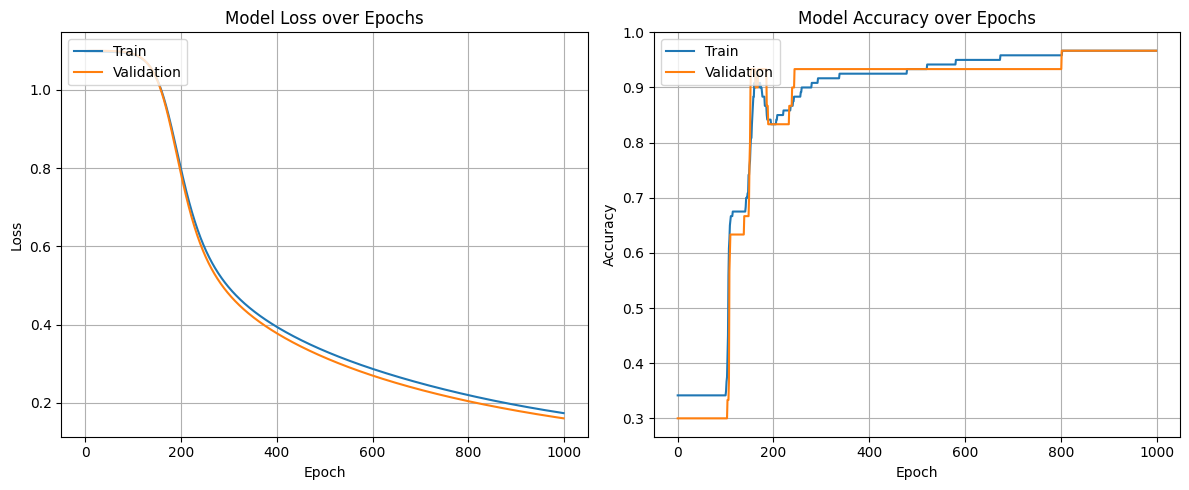

In [65]:
plt.figure(figsize=(12, 5))

# Plot training & validation loss values
plt.subplot(1, 2, 1)
plt.plot(history['loss'])
plt.plot(history['val_loss'])
plt.title('Model Loss over Epochs')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.grid(True)

# Plot training & validation accuracy values
plt.subplot(1, 2, 2)
plt.plot(history['accuracy'])
plt.plot(history['val_accuracy'])
plt.title('Model Accuracy over Epochs')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.grid(True)

plt.tight_layout()
plt.show()

In [64]:
def predict(X, W1, b1, W2, b2):
    _, _, _, A2 = forward_propagation(X, W1, b1, W2, b2)
    return np.argmax(A2, axis=1)

def calculate_accuracy(predictions, true_labels_ohe):
    true_labels = np.argmax(true_labels_ohe, axis=1)
    accuracy = np.mean(predictions == true_labels)
    return accuracy

# Make predictions on the test set
test_predictions = predict(X_test, W1_trained, b1_trained, W2_trained, b2_trained)

# Calculate accuracy
test_accuracy = calculate_accuracy(test_predictions, y_test_ohe)

print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

Test Accuracy: 96.67%
